# <span style="font-size:16pt; font-weight:bold;">Notebook 21: Comprehensive Multimodal Feature Inventory</span>


## <span style="font-size:14pt; font-weight:bold;">1. Setup and Loading</span>


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; from sklearn.decomposition import PCA; import warnings; warnings.filterwarnings('ignore')
REPO = Path.home() / 'projects' / 'music-prediction'
IMGS = REPO / 'results/figures/thesis'; ANALYSIS = REPO / 'results/analysis'; FEAT = REPO / 'ml/features'
IMGS.mkdir(parents=True,exist_ok=True); ANALYSIS.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','font.size':12,'axes.labelsize':14,'axes.titlesize':14})
print('Setup complete.')


Setup complete.


## <span style="font-size:14pt; font-weight:bold;">2. Modality Definitions and Loading</span>


In [2]:
MODS = {'audio':{'dim':23,'file':'X_{s}_audio.npy'},'text_stats':{'dim':5,'file':'X_{s}_text_stats.npy'},
        'sentiment':{'dim':2,'file':'X_{s}_sentiment.npy'},'mpnet':{'dim':768,'file':'X_{s}_mpnet.npy'},
        'vggish':{'dim':128,'file':'X_{s}_vggish.npy'},'mert':{'dim':768,'file':'X_{s}_mert.npy'},
        'panns':{'dim':2048,'file':'X_{s}_panns.npy'},'mel_stats':{'dim':512,'file':'X_{s}_mel_stats.npy'}}
total = sum(v['dim'] for v in MODS.values()); print(f'Total dim: {total}'); assert total==4254
def load_split(s):
    d={}
    for n,v in MODS.items():
        a=np.load(FEAT/v['file'].format(s=s)); assert a.shape[1]==v['dim'],f'{n} dim mismatch'
        assert np.isfinite(a).all(),f'{n} non-finite'; d[n]=a; print(f'  {s}/{n}: {a.shape}')
    return d
all_d={}; [all_d.update({s:load_split(s)}) for s in ['train','val','test']]
print('\nAll modalities loaded successfully.')


Total dim: 4254
  train/audio: (344428, 23)
  train/text_stats: (344428, 5)
  train/sentiment: (344428, 2)
  train/mpnet: (344428, 768)
  train/vggish: (344428, 128)
  train/mert: (344428, 768)
  train/panns: (344428, 2048)
  train/mel_stats: (344428, 512)
  val/audio: (72631, 23)
  val/text_stats: (72631, 5)
  val/sentiment: (72631, 2)
  val/mpnet: (72631, 768)
  val/vggish: (72631, 128)
  val/mert: (72631, 768)
  val/panns: (72631, 2048)
  val/mel_stats: (72631, 512)
  test/audio: (74573, 23)
  test/text_stats: (74573, 5)
  test/sentiment: (74573, 2)
  test/mpnet: (74573, 768)
  test/vggish: (74573, 128)
  test/mert: (74573, 768)
  test/panns: (74573, 2048)
  test/mel_stats: (74573, 512)

All modalities loaded successfully.


## <span style="font-size:14pt; font-weight:bold;">3. Quality Checks</span>


In [3]:
rows = []
for n in MODS:
    a = all_d['test'][n]
    nz = (np.abs(a).max(axis=1) < 1e-8).sum()
    rows.append({
        'Modality': n,
        'Dim': a.shape[1],
        'NaN': int(np.isnan(a).sum()),
        'Inf': int(np.isinf(a).sum()),
        'ZeroRows': int(nz),
        'ZeroPct': f'{nz / a.shape[0] * 100:.2f}%'
    })

qdf = pd.DataFrame(rows)
print(qdf.to_string(index=False))


  Modality  Dim  NaN  Inf  ZeroRows ZeroPct
     audio   23    0    0         0   0.00%
text_stats    5    0    0         0   0.00%
 sentiment    2    0    0         0   0.00%
     mpnet  768    0    0         0   0.00%
    vggish  128    0    0         0   0.00%
      mert  768    0    0         0   0.00%
     panns 2048    0    0         0   0.00%
 mel_stats  512    0    0         0   0.00%


## <span style="font-size:14pt; font-weight:bold;">4. PCA by Modality</span>


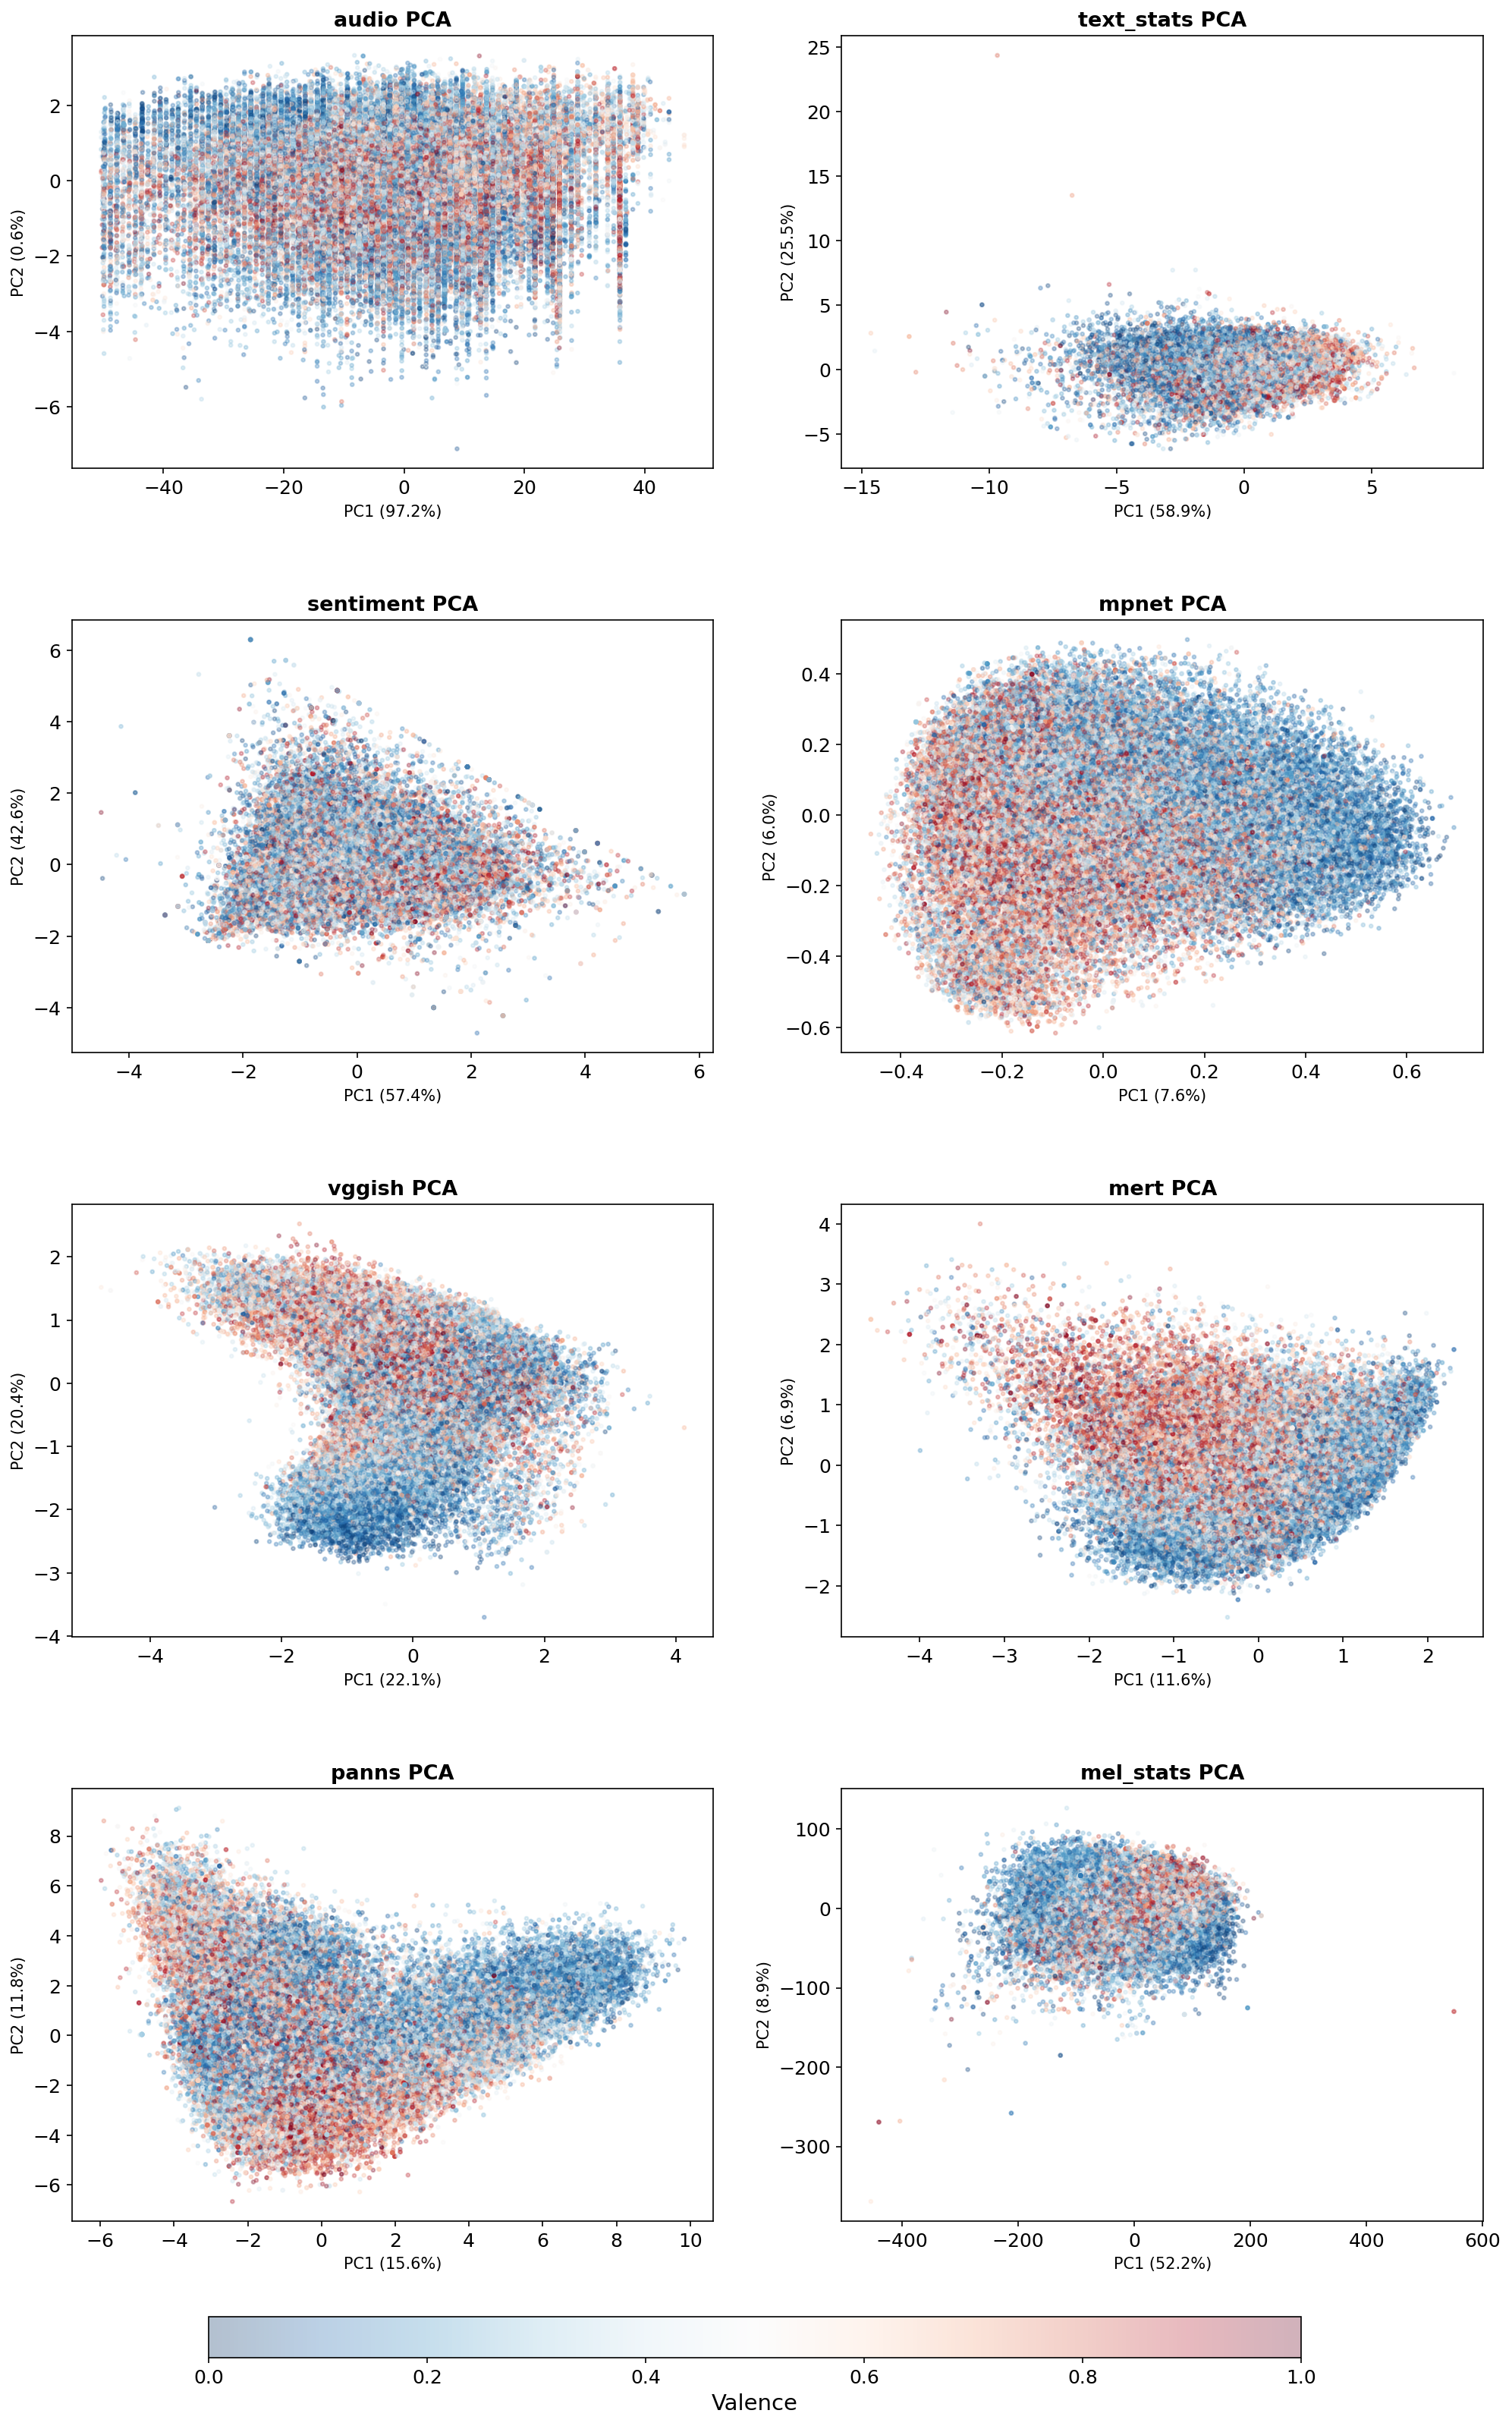

In [4]:
y_test = np.column_stack(
    [np.load(FEAT / f'y_test_{t}.npy') for t in ['valence', 'energy', 'danceability', 'popularity']]
)

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.ravel()

for idx, (n, v) in enumerate(MODS.items()):
    ax = axes[idx]
    a = all_d['test'][n]
    p = PCA(n_components=2, random_state=42)
    proj = p.fit_transform(a)

    sc = ax.scatter(
        proj[:, 0], proj[:, 1],
        c=y_test[:, 0], cmap='RdBu_r',
        alpha=0.3, s=5, vmin=0, vmax=1
    )
    ax.set_title(f'{n} PCA', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({p.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax.set_ylabel(f'PC2 ({p.explained_variance_ratio_[1]:.1%})', fontsize=10)

# Reserve extra bottom space and add a dedicated colorbar axis to avoid overlap
fig.subplots_adjust(hspace=0.35, wspace=0.2, bottom=0.08)
cax = fig.add_axes([0.2, 0.03, 0.6, 0.015])  # [left, bottom, width, height]
fig.colorbar(sc, cax=cax, orientation='horizontal', label='Valence')

fig.savefig(IMGS / '21_modality_pca.png')
plt.show()

## <span style="font-size:14pt; font-weight:bold;">5. Key Findings</span>


In [5]:
print('='*70); print('NOTEBOOK 21: KEY FINDINGS'); print('='*70)
print(f'1. All {len(MODS)} modalities loaded across 3 splits; total {total} features')
print('2. No NaN/Inf found in any modality')
print('3. Audio embedding coverage varies by modality')
qdf.to_csv(ANALYSIS/'21_feature_inventory_summary.csv',index=False)
print('\nNotebook 21 complete.')


NOTEBOOK 21: KEY FINDINGS
1. All 8 modalities loaded across 3 splits; total 4254 features
2. No NaN/Inf found in any modality
3. Audio embedding coverage varies by modality

Notebook 21 complete.
